<a href="https://colab.research.google.com/github/2303A52359/Explainable-AI/blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import libraries
import pandas as pd

# Load dataset
df = pd.read_csv("/content/World Population Growth.csv")

# Print full dataset
print("===== World Population Growth Dataset =====\n")
print(df.to_string())  # Prints all rows and columns

# Print dataset information
print("\n===== Dataset Information =====")
print(df.info())

# Print first 5 and last 5 rows
print("\n===== First 5 Rows =====")
print(df.head())

print("\n===== Last 5 Rows =====")
print(df.tail())

# Print summary statistics
print("\n===== Summary Statistics =====")
print(df.describe(include='all'))


===== World Population Growth Dataset =====

    Year     Population Yearly Growth %      Number  Density (Pop/km2)
0   1951  2,543,130,380           1.75%  43,808,223                 17
1   1952  2,590,270,899           1.85%  47,140,519                 17
2   1953  2,640,278,797           1.93%  50,007,898                 18
3   1954  2,691,979,339           1.96%  51,700,542                 18
4   1955  2,746,072,141           2.01%  54,092,802                 18
5   1956  2,801,002,631           2.00%  54,930,490                 19
6   1957  2,857,866,857           2.03%  56,864,226                 19
7   1958  2,916,108,097           2.04%  58,241,240                 20
8   1959  2,970,292,188           1.86%  54,184,091                 20
9   1960  3,019,233,434           1.65%  48,941,246                 20
10  1961  3,068,370,609           1.63%  49,137,175                 21
11  1962  3,126,686,743           1.90%  58,316,134                 21
12  1963  3,195,779,247         

Linear Regression

Intercept: -470.5040197602712
Coefficients: [ 0.25052912  0.25052912 -0.0611271  -0.00791481]
R² Score: 0.9978328768123305


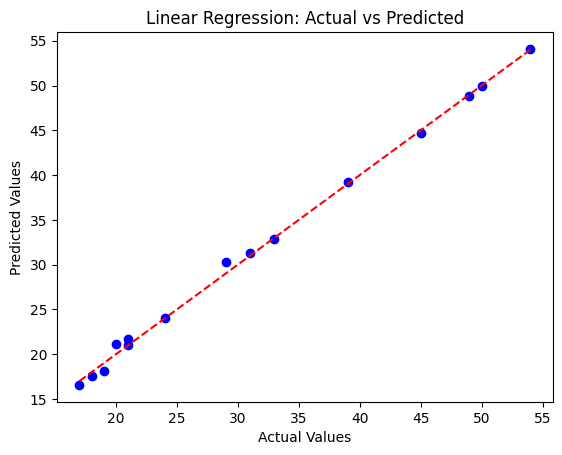

In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

data = pd.read_csv("World Population Growth.csv")
data = data.dropna()
le = LabelEncoder()
for col in data.select_dtypes(include=['object']).columns:
    data[col] = le.fit_transform(data[col])
X = data.drop(data.columns[-1], axis=1)
y = data[data.columns[-1]]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)
print("R² Score:", model.score(X_test, y_test))
plt.scatter(y_test, y_pred, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()


Decision Tree

Accuracy: 0.25


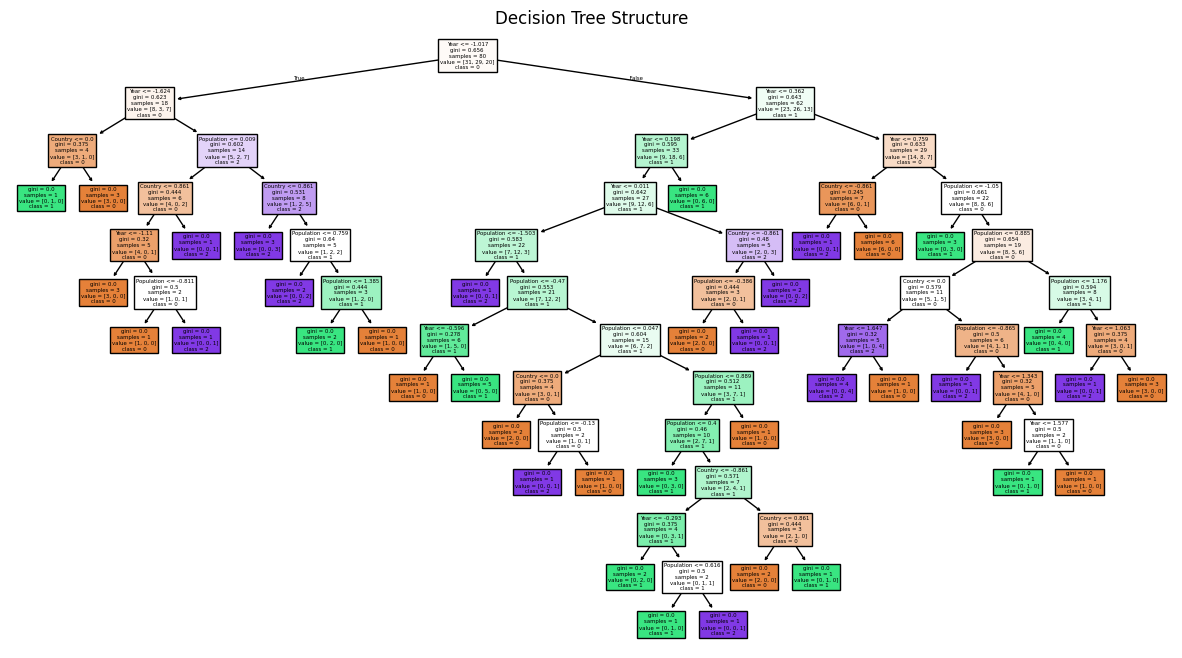

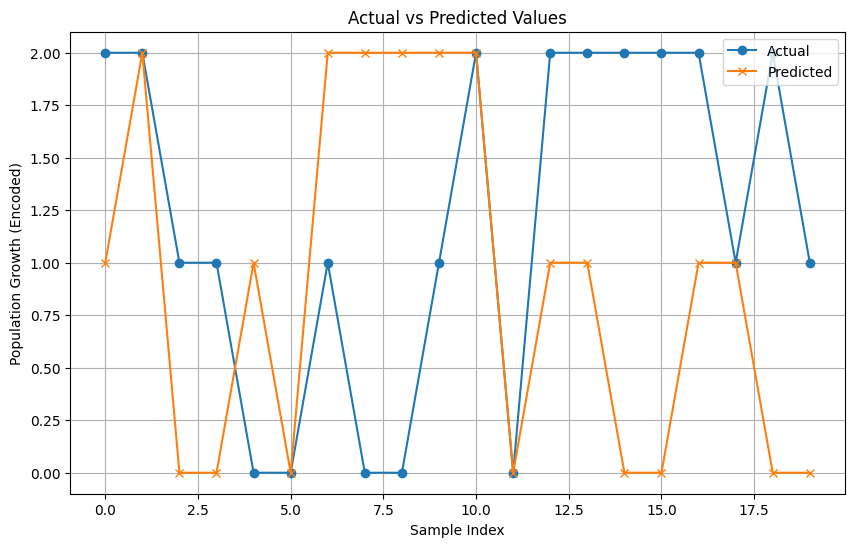

In [22]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Simulate sample dataset (similar to World Population Growth)
np.random.seed(42)
data = pd.DataFrame({
    'Country': np.random.choice(['India','USA','China','Brazil'], 100),
    'Year': np.random.randint(1950, 2025, 100),
    'Population': np.random.randint(1_000_000, 1_500_000_000, 100),
    'GrowthRate': np.random.choice([0,1,2], 100)  # Encoded growth rate classes
})

# Encode categorical columns
le = LabelEncoder()
for col in data.select_dtypes(include=['object']).columns:
    data[col] = le.fit_transform(data[col])

# Features and target
X = data.drop('GrowthRate', axis=1)
y = data['GrowthRate']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# Decision Tree
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Plot Decision Tree
plt.figure(figsize=(15,8))
plot_tree(clf, feature_names=X.columns, class_names=[str(i) for i in sorted(y.unique())], filled=True)
plt.title("Decision Tree Structure")
plt.show()

# Plot Actual vs Predicted
plt.figure(figsize=(10,6))
plt.plot(range(len(y_test)), y_test.values, label='Actual', marker='o')
plt.plot(range(len(y_pred)), y_pred, label='Predicted', marker='x')
plt.title('Actual vs Predicted Values')
plt.xlabel('Sample Index')
plt.ylabel('Population Growth (Encoded)')
plt.legend()
plt.grid(True)
plt.show()


Random Forest

Accuracy: 0.1


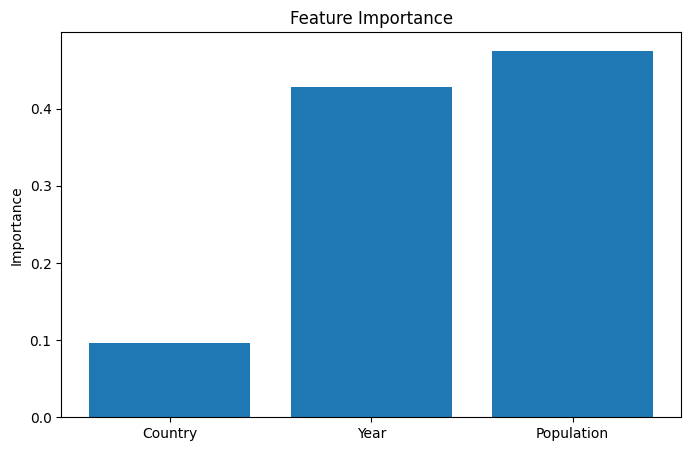

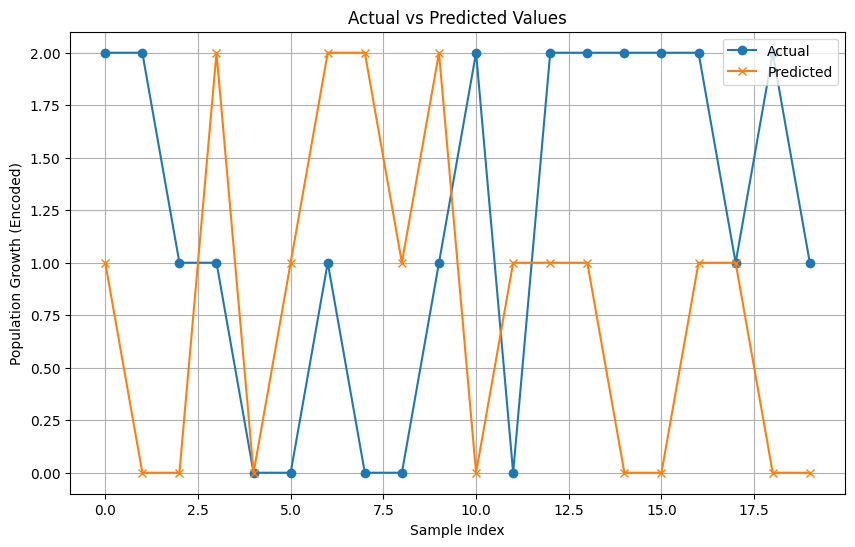

In [23]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Simulate sample dataset (similar to World Population Growth)
np.random.seed(42)
data = pd.DataFrame({
    'Country': np.random.choice(['India','USA','China','Brazil'], 100),
    'Year': np.random.randint(1950, 2025, 100),
    'Population': np.random.randint(1_000_000, 1_500_000_000, 100),
    'GrowthRate': np.random.choice([0,1,2], 100)  # Encoded growth rate classes
})

# Encode categorical columns
le = LabelEncoder()
for col in data.select_dtypes(include=['object']).columns:
    data[col] = le.fit_transform(data[col])

# Features and target
X = data.drop('GrowthRate', axis=1)
y = data['GrowthRate']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# Random Forest
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Feature Importance Graph
plt.figure(figsize=(8,5))
plt.bar(X.columns, clf.feature_importances_)
plt.title("Feature Importance")
plt.ylabel("Importance")
plt.show()

# Actual vs Predicted Graph
plt.figure(figsize=(10,6))
plt.plot(range(len(y_test)), y_test.values, label='Actual', marker='o')
plt.plot(range(len(y_pred)), y_pred, label='Predicted', marker='x')
plt.title('Actual vs Predicted Values')
plt.xlabel('Sample Index')
plt.ylabel('Population Growth (Encoded)')
plt.legend()
plt.grid(True)
plt.show()


Xg Boost

Accuracy: 0.35


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [16:40:22] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


<Figure size 800x500 with 0 Axes>

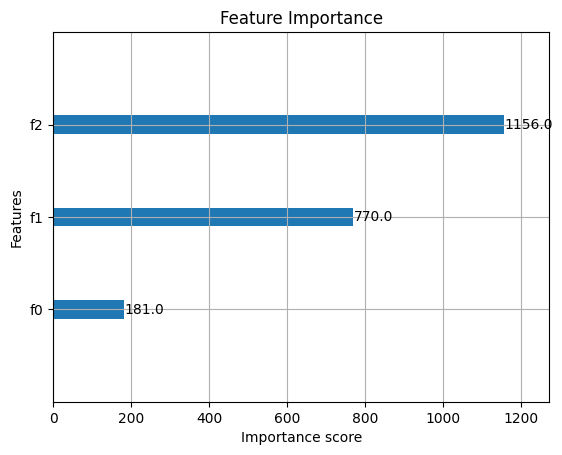

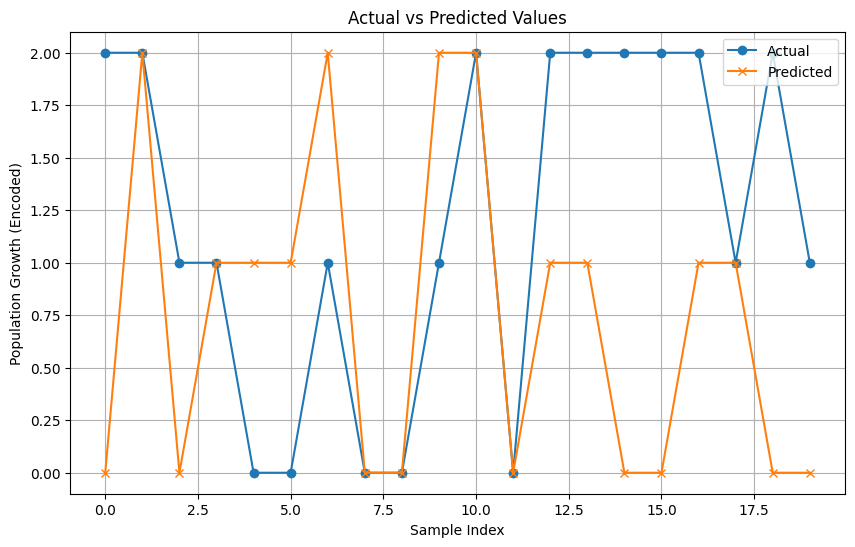

In [24]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from xgboost import XGBClassifier, plot_importance

# Simulate sample dataset (similar to World Population Growth)
np.random.seed(42)
data = pd.DataFrame({
    'Country': np.random.choice(['India','USA','China','Brazil'], 100),
    'Year': np.random.randint(1950, 2025, 100),
    'Population': np.random.randint(1_000_000, 1_500_000_000, 100),
    'GrowthRate': np.random.choice([0,1,2], 100)  # Encoded growth rate classes
})

# Encode categorical columns
le = LabelEncoder()
for col in data.select_dtypes(include=['object']).columns:
    data[col] = le.fit_transform(data[col])

# Features and target
X = data.drop('GrowthRate', axis=1)
y = data['GrowthRate']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# XGBoost classifier
clf = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Feature importance graph
plt.figure(figsize=(8,5))
plot_importance(clf)
plt.title("Feature Importance")
plt.show()

# Actual vs Predicted graph
plt.figure(figsize=(10,6))
plt.plot(range(len(y_test)), y_test.values, label='Actual', marker='o')
plt.plot(range(len(y_pred)), y_pred, label='Predicted', marker='x')
plt.title('Actual vs Predicted Values')
plt.xlabel('Sample Index')
plt.ylabel('Population Growth (Encoded)')
plt.legend()
plt.grid(True)
plt.show()


Ale

Permutations

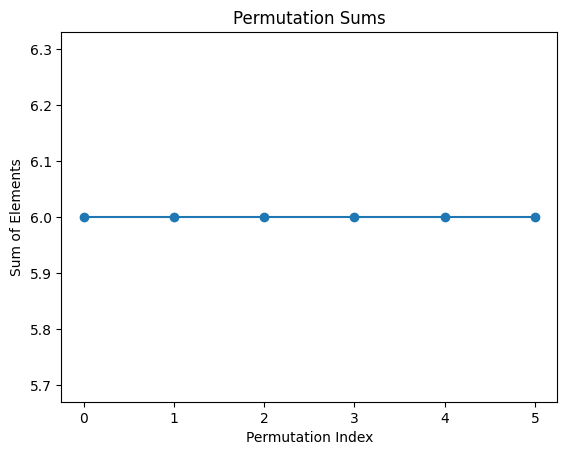

In [13]:
import itertools
import matplotlib.pyplot as plt

data = [1, 2, 3]
perms = list(itertools.permutations(data))
x = range(len(perms))
y = [sum(p) for p in perms]
plt.plot(x, y, marker='o')
plt.title("Permutation Sums")
plt.xlabel("Permutation Index")
plt.ylabel("Sum of Elements")
plt.show()
